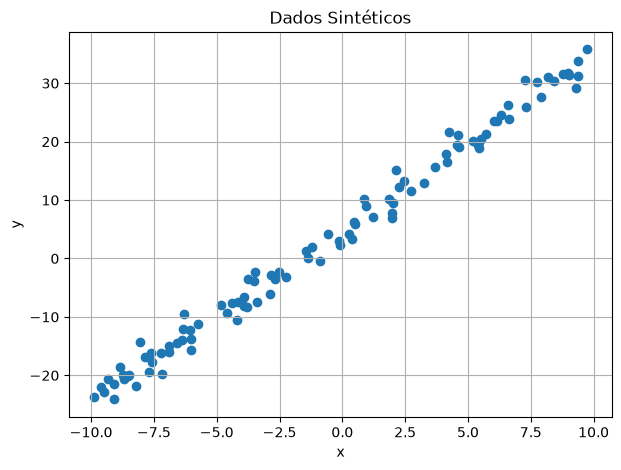

REGRESSÃO POR PSEUDO-INVERSA
Intercepto (b): 4.8845
Coeficiente (w): 2.9599
MSE: 2.6148
R² : 0.9924


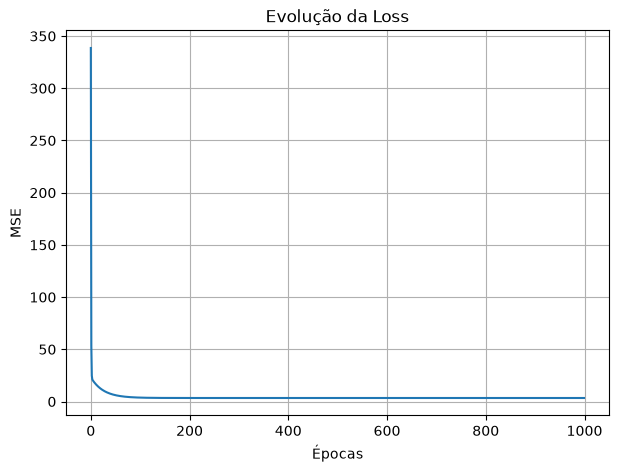



REDE NEURAL
Peso aprendido : 2.9599
Bias aprendido : 4.8845
MSE: 2.6148
R² : 0.9924


COMPARAÇÃO
Pseudo-inversa
MSE = 2.6148
R²  = 0.9924

Rede Neural
MSE = 2.6148
R²  = 0.9924


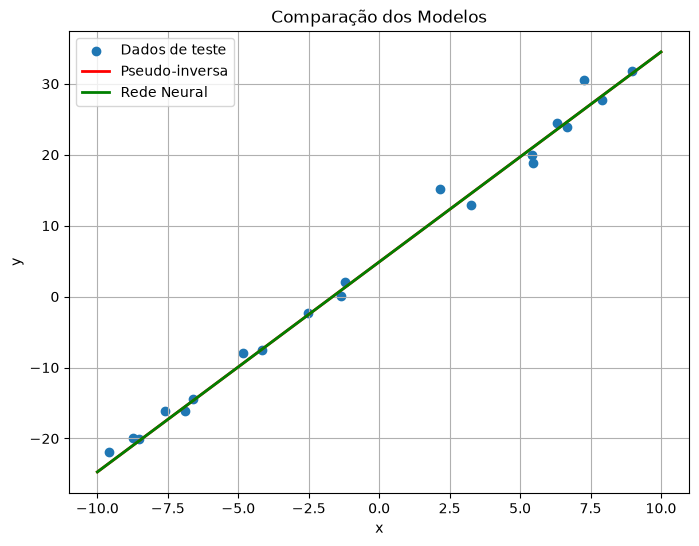

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================================
# 1. Gerando os dados sintéticos
# ==========================================================

np.random.seed(42)

N = 100

x = np.random.uniform(-10, 10, N)
ruido = np.random.normal(0, 2, N)
y = 3 * x + 5 + ruido

plt.figure(figsize=(7,5))
plt.scatter(x, y)
plt.title("Dados Sintéticos")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

# ==========================================================
# 2. Divisão treino/teste
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)

# ==========================================================
# 3. Regressão Linear - Pseudo-inversa
# ==========================================================

Xb_train = np.c_[np.ones((X_train.shape[0],1)), X_train]
Xb_test = np.c_[np.ones((X_test.shape[0],1)), X_test]

theta = np.linalg.pinv(Xb_train) @ y_train

b = theta[0]
w = theta[1]

print("="*50)
print("REGRESSÃO POR PSEUDO-INVERSA")
print("="*50)
print(f"Intercepto (b): {b:.4f}")
print(f"Coeficiente (w): {w:.4f}")

y_pred_pinv = Xb_test @ theta

mse_pinv = mean_squared_error(y_test, y_pred_pinv)
r2_pinv = r2_score(y_test, y_pred_pinv)

print(f"MSE: {mse_pinv:.4f}")
print(f"R² : {r2_pinv:.4f}")

# ==========================================================
# 4. Rede Neural
# ==========================================================

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)

y_train_t = torch.FloatTensor(y_train.reshape(-1,1))
y_test_t = torch.FloatTensor(y_test.reshape(-1,1))

model = nn.Linear(1,1)

criterion = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 1000

losses = []

for epoch in range(epochs):

    prediction = model(X_train_t)

    loss = criterion(prediction, y_train_t)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

# ==========================================================
# 5. Gráfico da Loss
# ==========================================================

plt.figure(figsize=(7,5))
plt.plot(losses)
plt.title("Evolução da Loss")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# ==========================================================
# 6. Avaliação da Rede Neural
# ==========================================================

with torch.no_grad():
    y_pred_nn = model(X_test_t).numpy()

mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

peso = model.weight.item()
bias = model.bias.item()

print("\n")
print("="*50)
print("REDE NEURAL")
print("="*50)
print(f"Peso aprendido : {peso:.4f}")
print(f"Bias aprendido : {bias:.4f}")
print(f"MSE: {mse_nn:.4f}")
print(f"R² : {r2_nn:.4f}")

# ==========================================================
# 7. Comparação dos Modelos
# ==========================================================

print("\n")
print("="*50)
print("COMPARAÇÃO")
print("="*50)

print("Pseudo-inversa")
print(f"MSE = {mse_pinv:.4f}")
print(f"R²  = {r2_pinv:.4f}")

print()

print("Rede Neural")
print(f"MSE = {mse_nn:.4f}")
print(f"R²  = {r2_nn:.4f}")

# ==========================================================
# 8. Visualização das retas
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, label="Dados de teste")

x_line = np.linspace(-10,10,100).reshape(-1,1)

X_line = np.c_[np.ones((100,1)), x_line]
y_line = X_line @ theta

plt.plot(x_line, y_line,
         color='red',
         linewidth=2,
         label='Pseudo-inversa')

with torch.no_grad():
    y_nn = model(torch.FloatTensor(x_line)).numpy()

plt.plot(x_line, y_nn,
         color='green',
         linewidth=2,
         label='Rede Neural')

plt.title("Comparação dos Modelos")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()